In [21]:
import numpy as np
import pandas as pd
import spice_net as spn

# Generating data

y = (x * z)³

In [22]:
np.random.seed(42)
x_data = np.random.uniform(low=-1.0, high=1.0, size=(6000,))  # TODO: Back to 3000
#z_data = np.random.standard_normal(size=(3000,))
z_data = np.random.uniform(low=-1.0, high=1.0, size=(6000,))
#result_data = np.power(x_data * z_data, 3)
result_data = x_data * z_data
#result_data = (x_data ** 2) - z_data ** 3

df = pd.DataFrame(np.array([x_data, z_data, result_data]).T, columns=['x_data', 'z_data', 'y_data'])
df

,x_data,z_data,y_data
0,-0.250920,0.296514,-0.074401
1,0.901429,-0.655227,-0.590641
2,0.463988,0.744789,0.345573
3,0.197317,0.226232,0.044640
4,-0.687963,-0.685592,0.471662
...,...,...,...
5995,0.368871,-0.990711,-0.365444
5996,0.006441,0.747337,0.004813
5997,0.530298,-0.385350,-0.204350
5998,-0.029419,0.877178,-0.025805


In [23]:


som_size = 50

som_1 = spn.SpiceNetSom(n_neurons=som_size,
                        key='x_data',
                        value_range_start=df['x_data'].min(),
                        value_range_end=df['x_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

som_2 = spn.SpiceNetSom(n_neurons=som_size,
                        key='z_data',
                        value_range_start=df['z_data'].min(),
                        value_range_end=df['z_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

som_3 = spn.SpiceNetSom(n_neurons=som_size,
                        key='y_data',
                        value_range_start=df['y_data'].min(),
                        value_range_end=df['y_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

correlation_matrix = spn.SpiceNetHcm([som_1, som_2, som_3], spn.ConstLRF(0.8), spn.ConstLRF(0.8))

spice_net = spn.SpiceNet(correlation_matrix)

In [24]:
input_data = df[['x_data', 'z_data']].apply(lambda row: row.to_numpy(), axis=1).tolist()
training_data = {
    'x_data': df['x_data'].tolist(),
    'z_data': df['z_data'].tolist(),
    'y_data': df['y_data'].tolist()
}
spice_net.fit(training_data, epochs_on_batch=10, batch_size=None, print_output=True)


100%|██████████| 1/1 [01:30<00:00, 90.59s/it]

Time spend on the Components: 
Som: 20.783698558807373 s | Convolution Matrix: 69.80222415924072 s


In [25]:
#np.save('gpt_imp', correlation_matrix.get_matrix())

In [26]:
#spn.plot_som(som_1, True)
spn.plot_som(som_2, True)
#spn.plot_hcm(correlation_matrix)
spn.plot_hcm(correlation_matrix, filter_start=190, height=900)

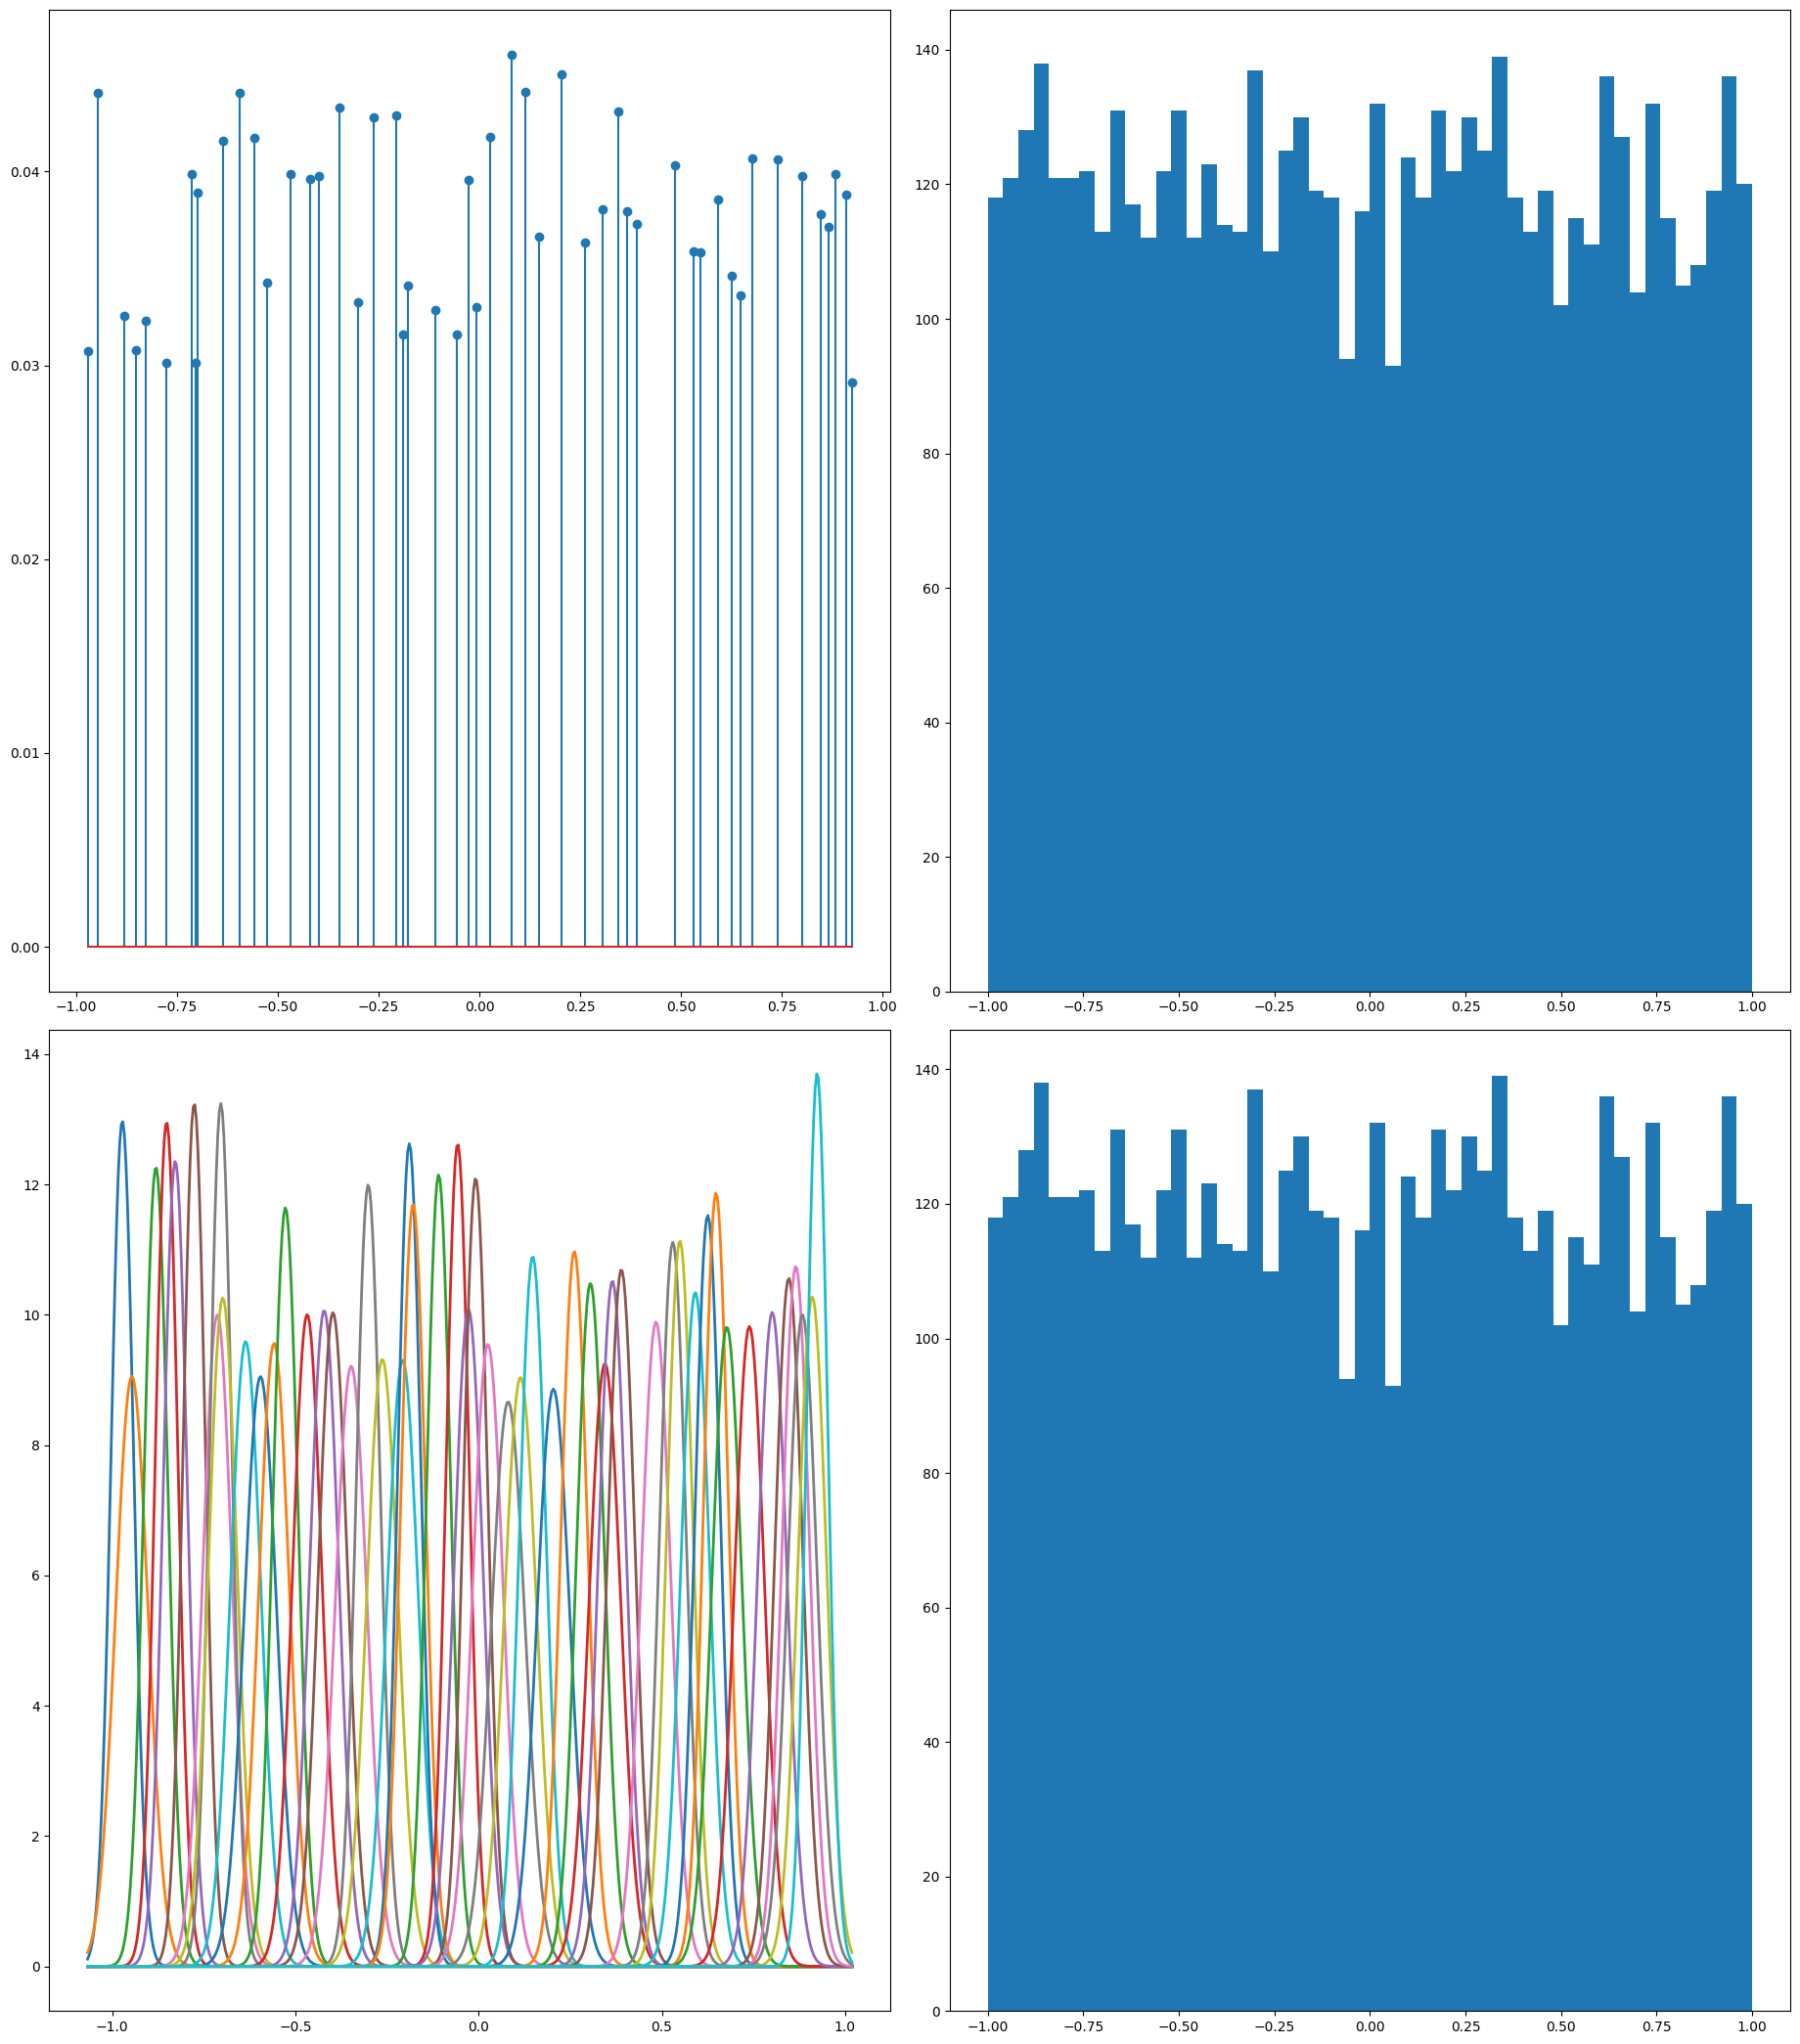

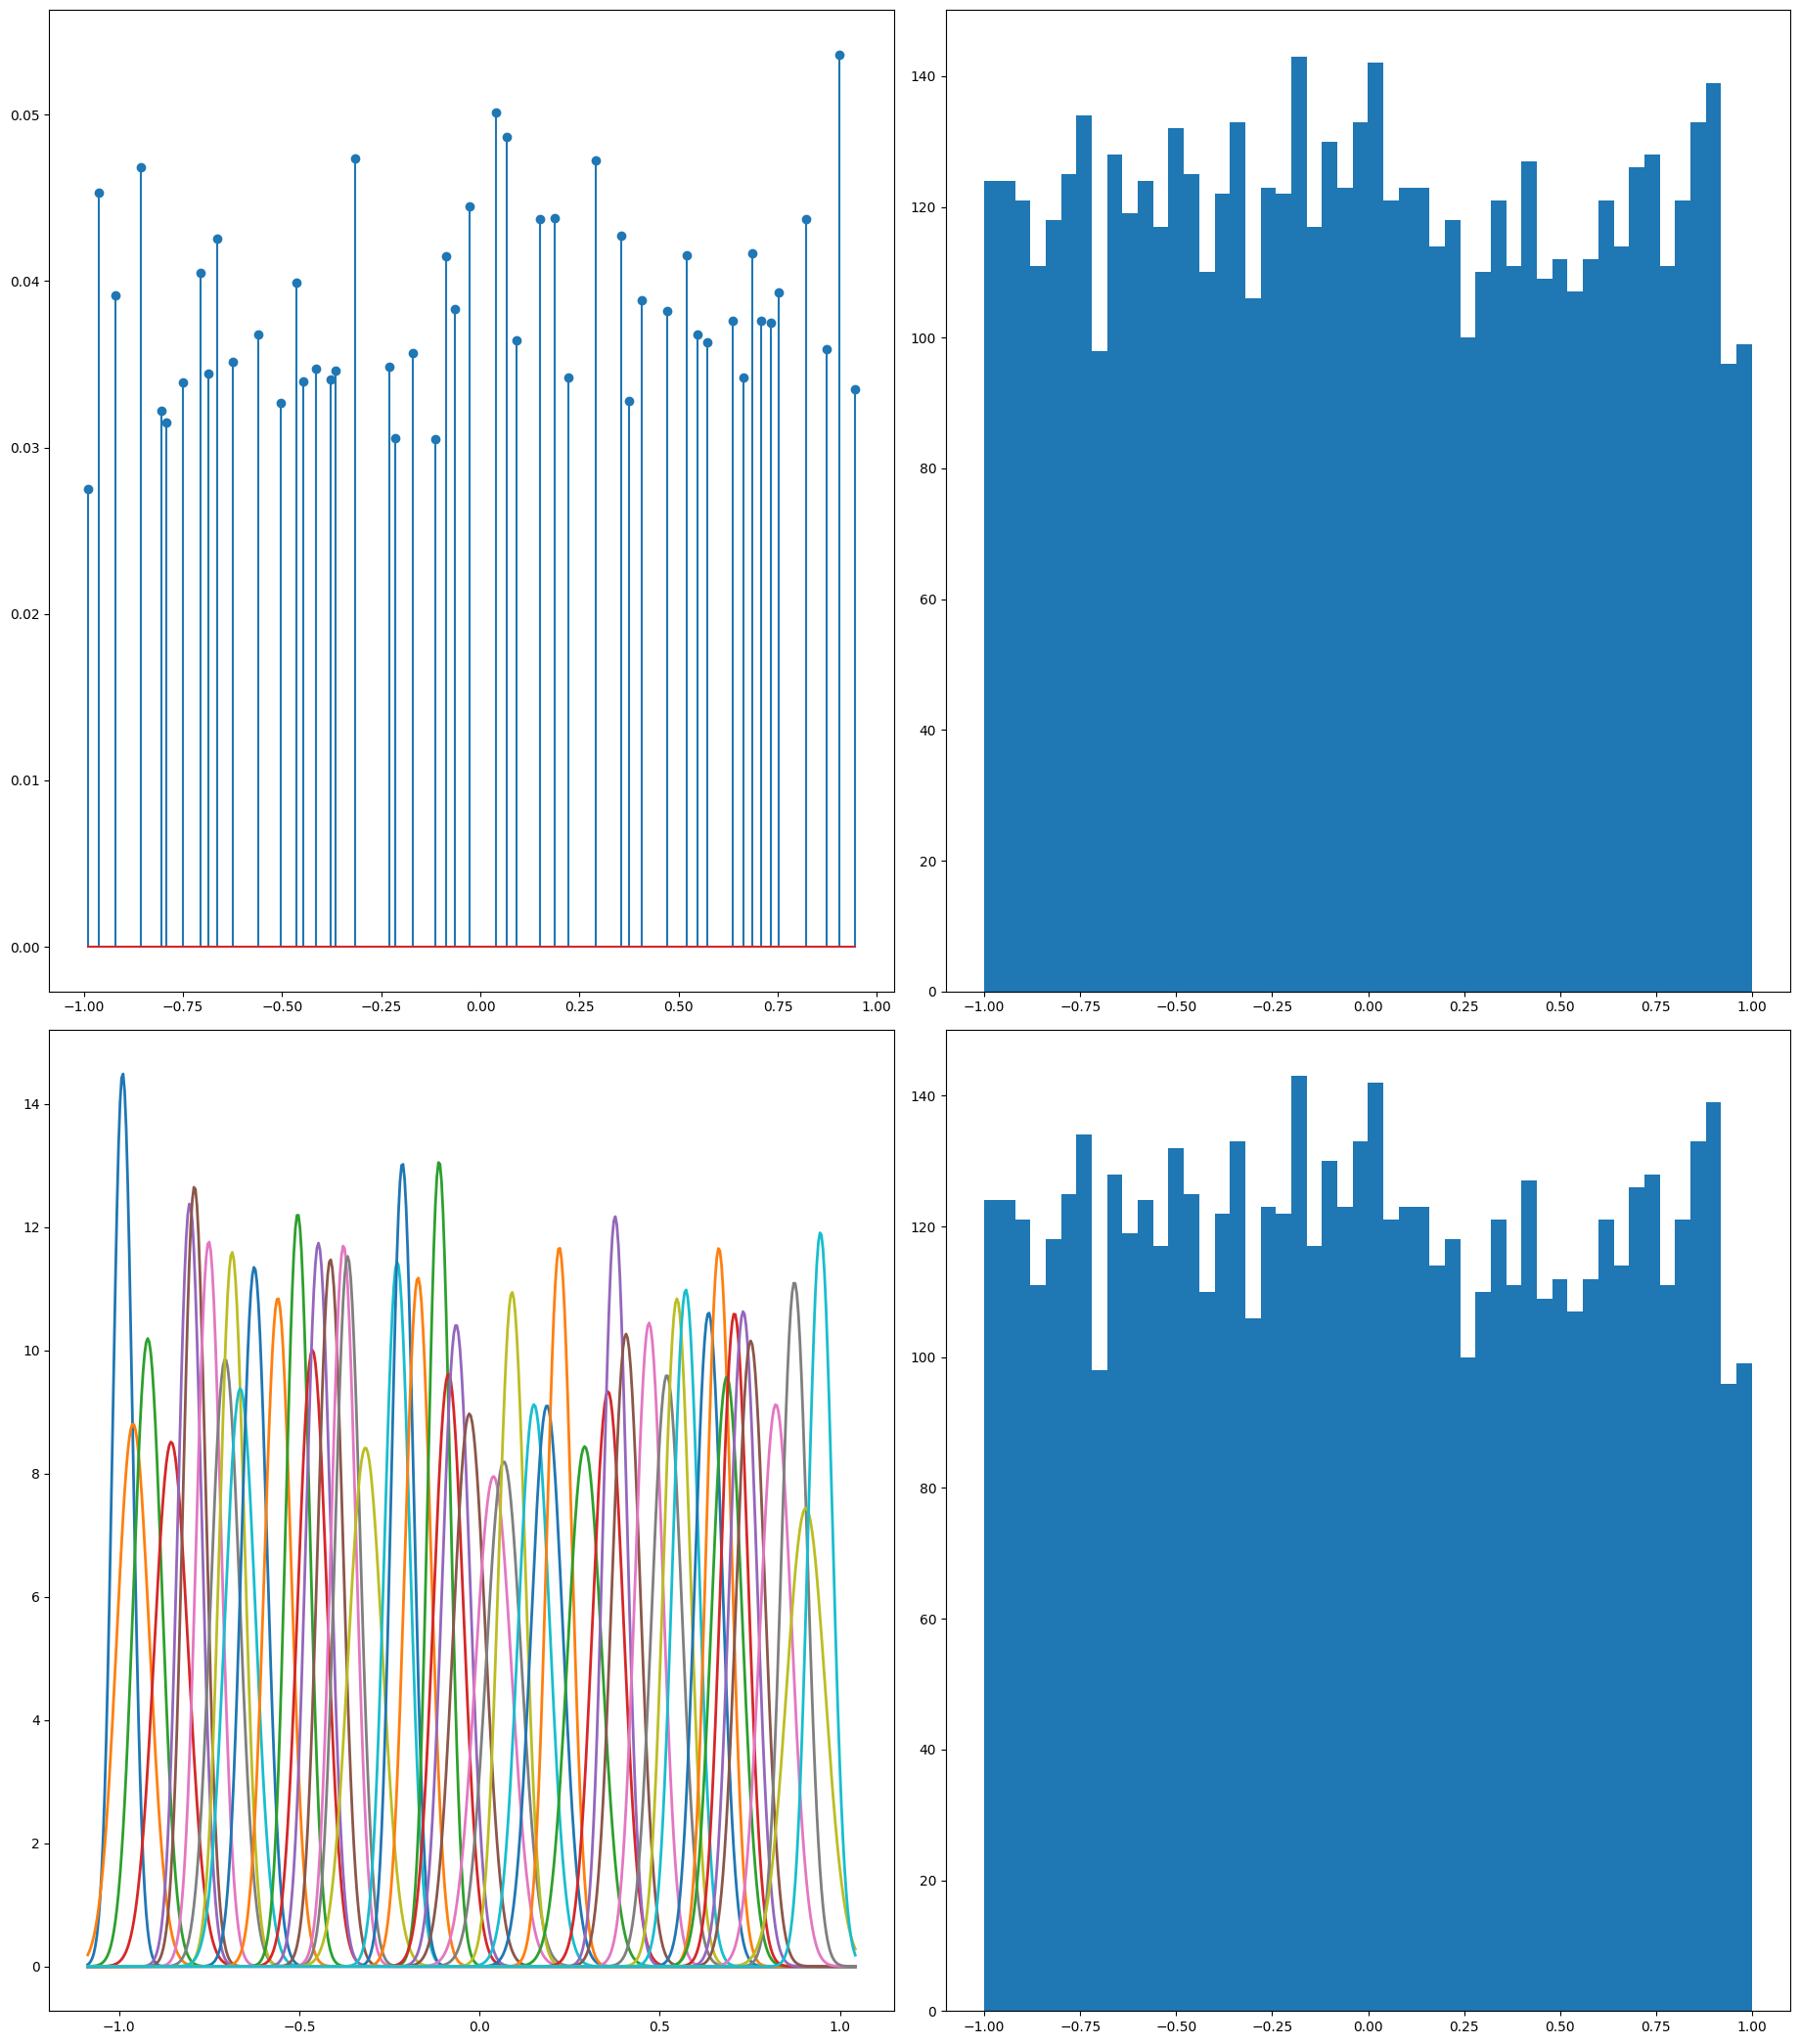

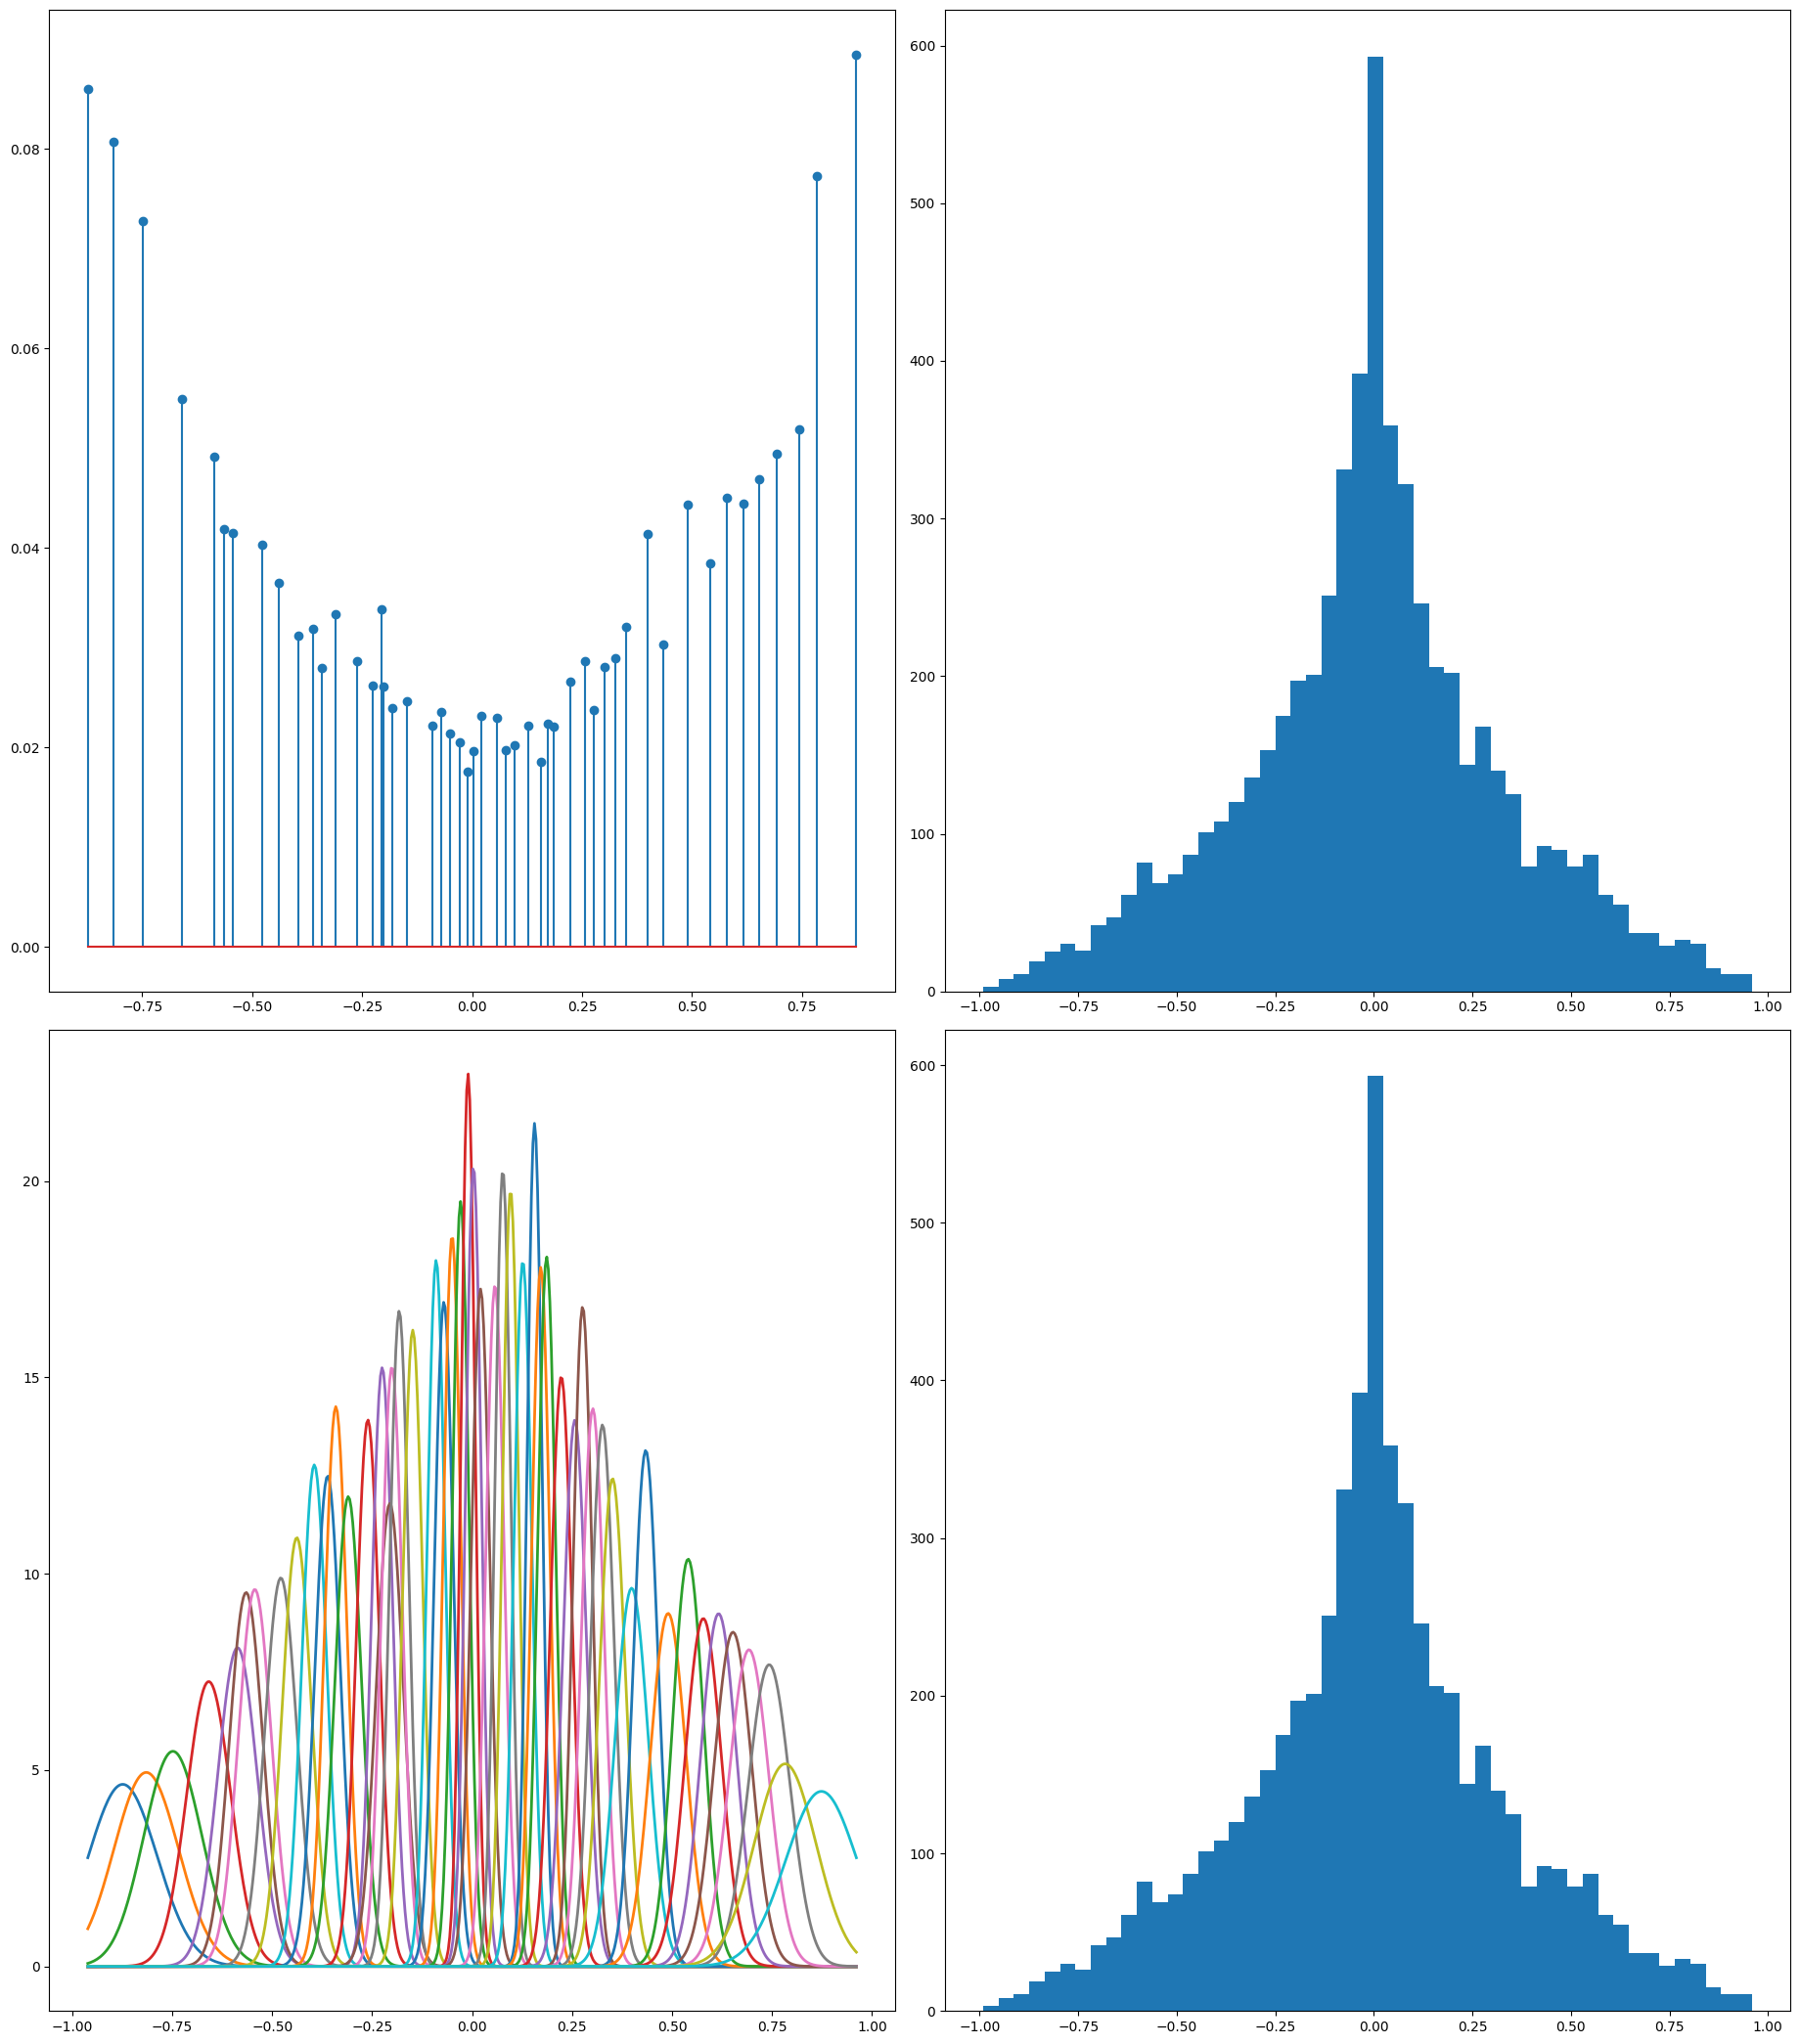

In [27]:

spn.plot_som_comparison_to_data(som_1, df['x_data'].tolist())
spn.plot_som_comparison_to_data(som_2, df['z_data'].tolist())
spn.plot_som_comparison_to_data(som_3, df['y_data'].tolist())

In [28]:
test_set = df.sample(1000)
test_set.sort_values(by=['y_data'])
errors = []
errors_distance = []
predicted_values = []

for _, row in test_set.iterrows():
    test_data = row
    result_test_value = test_data['y_data']
    predicted = spice_net.decode({'x_data': test_data['x_data'], 'z_data': test_data['z_data']},
                                 decoder='bert-optimizer')
    predicted_values.append(predicted)
    errors.append(abs(predicted - result_test_value) / 2 * 100)
    errors_distance.append(abs(predicted - result_test_value))
    print(f'Error: {errors[-1]:.6f},\t Predicted: {predicted:.6f},\t Actual: {result_test_value:.6f}')

print(f'Mean Error distance {np.mean(np.array(errors_distance))}')
print(f'Mean Error in % {np.mean(np.array(errors))}')
print(f'Median Error in % {np.median(np.array(errors))}')
print(f'Error std {np.std(np.array(errors))}')

Error: 0.978568,	 Predicted: 0.253057,	 Actual: 0.233486
Error: 12.185102,	 Predicted: -0.002696,	 Actual: 0.241006
Error: 0.718942,	 Predicted: -0.240800,	 Actual: -0.226421
Error: 0.423295,	 Predicted: -0.165034,	 Actual: -0.156568
Error: 1.179764,	 Predicted: -0.283350,	 Actual: -0.306945
Error: 8.573058,	 Predicted: 0.169920,	 Actual: -0.001541
Error: 0.858551,	 Predicted: 0.230551,	 Actual: 0.213380
Error: 0.475488,	 Predicted: -0.075197,	 Actual: -0.065687
Error: 0.124717,	 Predicted: 0.033451,	 Actual: 0.030956
Error: 0.435874,	 Predicted: 0.087113,	 Actual: 0.095830
Error: 0.252228,	 Predicted: -0.322653,	 Actual: -0.317609
Error: 35.040471,	 Predicted: 0.059405,	 Actual: -0.641404
Error: 1.911633,	 Predicted: -0.277947,	 Actual: -0.316179
Error: 1.147932,	 Predicted: 0.167140,	 Actual: 0.144181
Error: 0.053661,	 Predicted: 0.514318,	 Actual: 0.515391
Error: 1.000311,	 Predicted: 0.101871,	 Actual: 0.081864
Error: 0.839119,	 Predicted: -0.212937,	 Actual: -0.229719
Error: 0.102

In [29]:
import plotly.express as px

direction = test_set['y_data'].to_numpy() - np.array(predicted_values)
error_df = pd.DataFrame(
    {'Index': range(1, len(errors) + 1),
     'Real': test_set['y_data'],
     'Distance': errors_distance,
     'dir': direction.tolist()})
fig = px.scatter(error_df, x="Index", y="Real", error_y="Distance")
fig.add_scatter(x=error_df['Index'].to_numpy(), y=predicted_values, fillcolor='orange', mode='markers',
                name='Predicted', zorder=1000)
#fig.add_scatter(x=error_df['Index'].to_numpy(), y=error_df['Real'].to_numpy(), fillcolor='green')
fig.show()